# Climate Anomalies
## What they are, why we use them, and how to calculate them

---

## What is a Climate Anomaly?

Imagine you're keeping track of the temperature every week for 30 years. Some weeks are hot, some are cold — and that's totally normal. But what if you want to know: **was this particular week *unusually* warm or cold compared to what's typical?**

That's exactly what a **climate anomaly** tells you.

An anomaly is simply the **difference between an observed value and the long-term average** (called the *climatology* or *baseline*) for that same time period:

$$\text{Anomaly} = \text{Observed Value} - \text{Long-term Average}$$

- A **positive anomaly** → the observed value was **warmer than average**
- A **negative anomaly** → the observed value was **cooler than average**
- An anomaly of **zero** → right on average

---

## Why Do Climate Scientists Use Anomalies?

You might wonder: why not just plot the raw temperature? Here are a few good reasons:

1. **Removes location bias.** A temperature of 15°C means something very different in Alaska vs. Florida. Anomalies put both places on the same footing — we're asking "how different was it from *normal* for that place?"

2. **Reveals trends more clearly.** Raw temperatures have a large seasonal cycle (summers are hot, winters are cold) that can hide long-term trends. Anomalies strip away that background noise.

3. **Enables comparison across regions.** If Alaska and Texas both show a +2°C anomaly in the same week, that's meaningful — even though their actual temperatures are completely different.

4. **Highlights extremes.** Large positive or negative anomalies flag truly unusual events — heat waves, cold snaps, and other extremes stand out immediately.

This is why virtually every major climate dataset — from NOAA to NASA GISS — reports anomalies rather than (or in addition to) raw values.

---

## The Baseline Period

The "long-term average" is computed over a defined **baseline period** — typically 30 years. The World Meteorological Organization (WMO) currently uses **1991–2020** as the standard baseline, though you may also see 1961–1990 or 1981–2010 used in older datasets.

The choice of baseline matters: an anomaly is always relative to whatever you define as "normal."

---

## Setting Up: Generate a Synthetic Dataset

We'll create a realistic synthetic dataset of **weekly average temperatures** over **30 years** for an imaginary mid-latitude station. The data includes:
- A realistic seasonal cycle (cold winters, warm summers)
- Year-to-year variability (random noise)
- A small long-term warming trend (~0.03°C/year) to make it interesting

In [1]:
# Import the libraries we will use.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.cm import RdBu_r

This code block below creates a dataframe with generic climate data in it. You can ignore this code block.

In [ ]:
# For reproducibility
rng = np.random.default_rng(seed=42)

# --- Generate synthetic weekly temperature data ---
start_date = '1993-01-01'
n_years = 30
dates = pd.date_range(start=start_date, periods=n_years * 52, freq='W')
n_weeks = len(dates)

# Day of year (used to compute the seasonal cycle)
day_of_year = dates.day_of_year.values

# Seasonal cycle: peaks in late July (~day 205), troughs in late January (~day 25)
seasonal = 12.0 * np.cos(2 * np.pi * (day_of_year - 205) / 365.25)

# Long-term mean
mean_temp = 8.0  # °C, mid-latitude station

# Weak linear warming trend
year_fraction = (dates - dates[0]).days.values / 365.25
trend = 0.03 * year_fraction

# Random interannual + week-to-week variability
noise = rng.normal(0, 2.5, n_weeks)

# Combine
temperature = mean_temp + seasonal + trend + noise

# Build a DataFrame
df = pd.DataFrame({'date': dates, 'temperature_C': temperature})
df['year'] = df['date'].dt.year
df['week'] = df['date'].dt.isocalendar().week.astype(int)

Dataset: 1560 weekly observations (1993–2022)
Temperature range: -10.1°C to 25.9°C


,date,temperature_C,year,week
0,1993-01-03,-2.577833,1993,53
1,1993-01-10,-6.328503,1993,1
2,1993-01-17,-2.071462,1993,2
3,1993-01-24,-1.642175,1993,3
4,1993-01-31,-8.743447,1993,4


# Start Here

The above code block has created a temperature dataset. The code below will show you what that dataset looks like. The dataset is in a Pandas dataframe and the variable name for the dataframe is `df`

In [3]:
print(f"Dataset: {len(df)} weekly observations ({df['year'].min()}–{df['year'].max()})")
print(f"Temperature range: {df['temperature_C'].min():.1f}°C to {df['temperature_C'].max():.1f}°C")
df.head()

Dataset: 1560 weekly observations (1993–2022)
Temperature range: -10.1°C to 25.9°C


,date,temperature_C,year,week
0,1993-01-03,-2.577833,1993,53
1,1993-01-10,-6.328503,1993,1
2,1993-01-17,-2.071462,1993,2
3,1993-01-24,-1.642175,1993,3
4,1993-01-31,-8.743447,1993,4


---
## Step 1: Compute the Climatology

The **climatology** is the long-term average for each week of the year. We calculate the mean temperature for week 1 (across all 30 years), week 2, week 3, and so on up to week 52.

This gives us a 52-value "typical year" that captures the seasonal cycle.

Climatological weekly mean temperatures (°C):
week
1     -3.31
2     -3.61
3     -3.36
4     -3.17
5     -3.04
6     -3.06
7     -2.61
8     -1.76
9     -0.89
10     1.11
11     1.14
12     2.86
13     4.09
14     5.01
15     6.85
16     8.41
17     8.37
18    11.51
19    12.43
20    13.77
21    15.25
22    16.11
23    16.97
24    17.53
25    18.91
26    19.23
27    19.20
28    20.15
29    20.45
30    19.93
31    20.84
32    19.53
33    18.92
34    18.22
35    17.13
36    17.14
37    15.42
38    13.87
39    13.57
40    12.11
41     9.63
42     8.46
43     7.12
44     6.26
45     4.27
46     2.89
47     1.77
48     1.01
49    -0.43
50    -0.49
51    -1.03
52    -2.51
53    -3.79
Name: clim_temp_C, dtype: float64


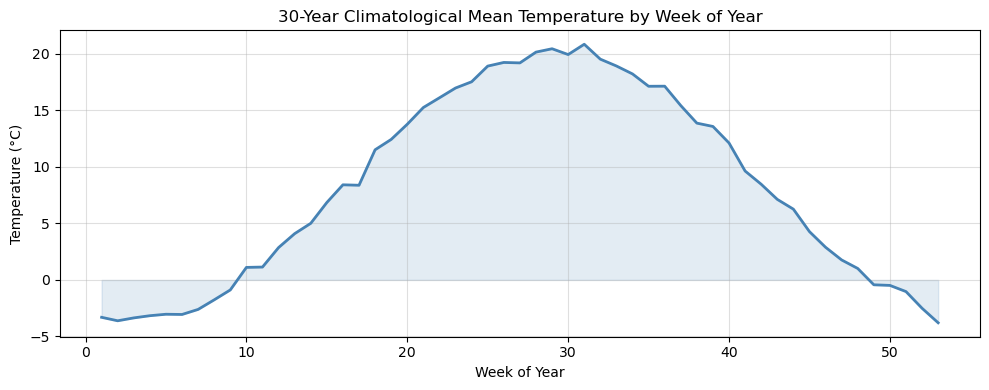

In [2]:
# Compute the climatology: mean temperature for each week of year
climatology = df.groupby('week')['temperature_C'].mean()
climatology.name = 'clim_temp_C'

print("Climatological weekly mean temperatures (°C):")
print(climatology.round(2))

# Plot the climatology
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(climatology.index, climatology.values, color='steelblue', linewidth=2)
ax.fill_between(climatology.index, climatology.values, alpha=0.15, color='steelblue')
ax.set_xlabel('Week of Year')
ax.set_ylabel('Temperature (°C)')
ax.set_title('30-Year Climatological Mean Temperature by Week of Year')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

---
## Step 2: Calculate the Anomalies

Now we subtract the climatological mean for each week from the observed temperature:

$$T'(\text{week}, \text{year}) = T(\text{week}, \text{year}) - \overline{T}(\text{week})$$

where $\overline{T}(\text{week})$ is the climatological mean for that week.

In [3]:
# Merge climatology back onto the full timeseries
df = df.merge(climatology, on='week', how='left')

# Compute the anomaly
df['anomaly_C'] = df['temperature_C'] - df['clim_temp_C']

print(f"Anomaly range: {df['anomaly_C'].min():.2f}°C to {df['anomaly_C'].max():.2f}°C")
print(f"Mean anomaly (should be ~0): {df['anomaly_C'].mean():.4f}°C")

df[['date', 'week', 'temperature_C', 'clim_temp_C', 'anomaly_C']].head(10)

Anomaly range: -9.57°C to 7.65°C
Mean anomaly (should be ~0): -0.0000°C


,date,week,temperature_C,clim_temp_C,anomaly_C
0,1993-01-03,53,-2.577833,-3.792467,1.214633
1,1993-01-10,1,-6.328503,-3.307187,-3.021316
2,1993-01-17,2,-2.071462,-3.614704,1.543242
3,1993-01-24,3,-1.642175,-3.359179,1.717004
4,1993-01-31,4,-8.743447,-3.165402,-5.578045
5,1993-02-07,5,-6.821696,-3.036305,-3.785392
6,1993-02-14,6,-2.779482,-3.056113,0.276631
7,1993-02-21,7,-3.261731,-2.608545,-0.653186
8,1993-02-28,8,-1.733459,-1.760986,0.027527
9,1993-03-07,9,-2.903973,-0.885177,-2.018796


---
## Step 3: Plot the Anomalies

The standard way to visualize anomalies is a **bar chart** (or "bar graph") where:
- **Red bars** indicate **positive anomalies** (warmer than average)
- **Blue bars** indicate **negative anomalies** (cooler than average)

This is sometimes called a "temperature anomaly stripe" or "anomaly bar chart."

We'll plot the full 30-year record, and then zoom in on a single year.

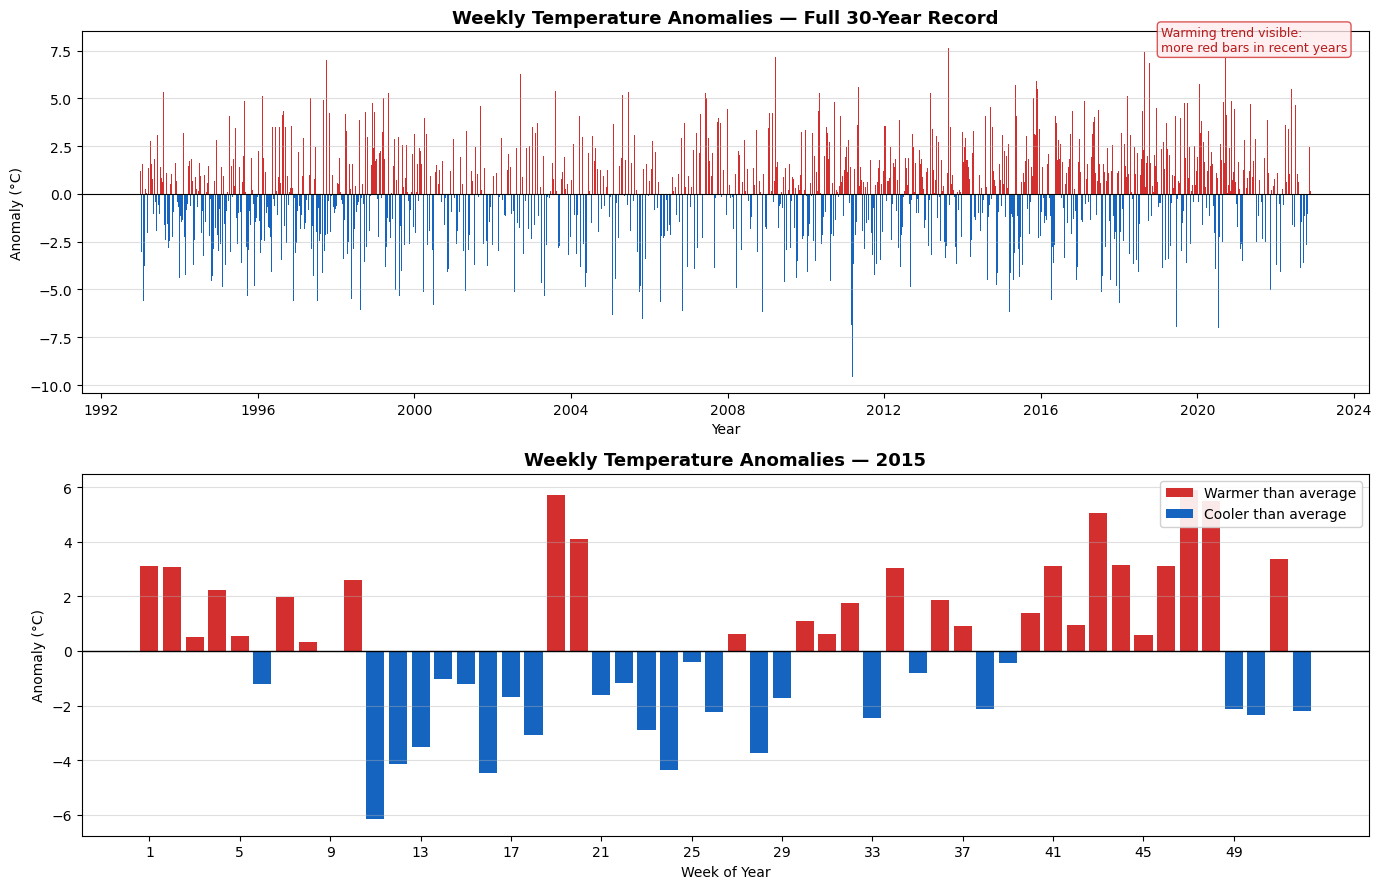

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# --- Top panel: Full 30-year weekly anomaly record ---
ax1 = axes[0]
colors_full = ['#D32F2F' if v >= 0 else '#1565C0' for v in df['anomaly_C']]
ax1.bar(df['date'], df['anomaly_C'], color=colors_full, width=6, linewidth=0)
ax1.axhline(0, color='black', linewidth=0.8)
ax1.set_title('Weekly Temperature Anomalies — Full 30-Year Record', fontsize=13, fontweight='bold')
ax1.set_ylabel('Anomaly (°C)')
ax1.set_xlabel('Year')
ax1.grid(True, axis='y', alpha=0.4)

# Add a note about the warming trend
ax1.annotate('Warming trend visible:\nmore red bars in recent years',
             xy=(df['date'].iloc[-200], 7.5), fontsize=9, color='#B71C1C',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFEBEE', edgecolor='#D32F2F', alpha=0.8))

# --- Bottom panel: Single year zoom ---
year_to_plot = 2015
df_year = df[df['year'] == year_to_plot]

ax2 = axes[1]
colors_yr = ['#D32F2F' if v >= 0 else '#1565C0' for v in df_year['anomaly_C']]
bars = ax2.bar(df_year['week'], df_year['anomaly_C'], color=colors_yr, width=0.8)
ax2.axhline(0, color='black', linewidth=1.0)
ax2.set_title(f'Weekly Temperature Anomalies — {year_to_plot}', fontsize=13, fontweight='bold')
ax2.set_ylabel('Anomaly (°C)')
ax2.set_xlabel('Week of Year')
ax2.set_xticks(range(1, 53, 4))
ax2.grid(True, axis='y', alpha=0.4)

# Add a legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#D32F2F', label='Warmer than average'),
                   Patch(facecolor='#1565C0', label='Cooler than average')]
ax2.legend(handles=legend_elements, loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.show()

---
## Step 4: Annual Mean Anomalies

We can also average the weekly anomalies by year to get **annual mean anomalies** — this smooths out week-to-week noise and shows the long-term trend more clearly.

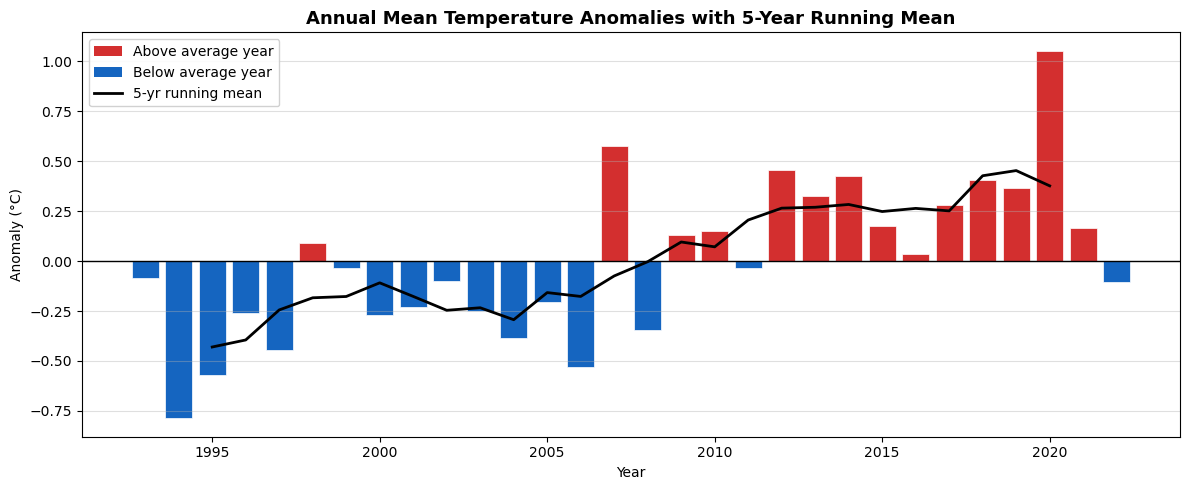


Annual mean anomalies (°C):
year
1993   -0.086
1994   -0.787
1995   -0.572
1996   -0.261
1997   -0.444
1998    0.090
1999   -0.035
2000   -0.268
2001   -0.229
2002   -0.101
2003   -0.249
2004   -0.383
2005   -0.205
2006   -0.528
2007    0.577
2008   -0.346
2009    0.130
2010    0.152
2011   -0.035
2012    0.456
2013    0.326
2014    0.428
2015    0.174
2016    0.035
2017    0.279
2018    0.404
2019    0.365
2020    1.053
2021    0.165
2022   -0.103


In [5]:
# Compute annual mean anomalies
annual_anomaly = df.groupby('year')['anomaly_C'].mean()

fig, ax = plt.subplots(figsize=(12, 5))

colors_ann = ['#D32F2F' if v >= 0 else '#1565C0' for v in annual_anomaly.values]
ax.bar(annual_anomaly.index, annual_anomaly.values, color=colors_ann, edgecolor='white', linewidth=0.5)
ax.axhline(0, color='black', linewidth=1.0)

# Add a running 5-year mean
running_mean = annual_anomaly.rolling(window=5, center=True).mean()
ax.plot(running_mean.index, running_mean.values, color='black', linewidth=2.0,
        label='5-year running mean', zorder=5)

ax.set_title('Annual Mean Temperature Anomalies with 5-Year Running Mean',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Anomaly (°C)')
ax.set_xlabel('Year')
ax.legend()
ax.grid(True, axis='y', alpha=0.4)

# Add legend patches
legend_elements = [Patch(facecolor='#D32F2F', label='Above average year'),
                   Patch(facecolor='#1565C0', label='Below average year')]
ax.legend(handles=legend_elements + [plt.Line2D([0], [0], color='black', lw=2, label='5-yr running mean')],
          loc='upper left', framealpha=0.9)

plt.tight_layout()
plt.show()

print("\nAnnual mean anomalies (°C):")
print(annual_anomaly.round(3).to_string())

---
## Summary

| Step | What we did |
|------|-------------|
| 1 | Computed the **climatology** — the long-term weekly mean temperature |
| 2 | Subtracted the climatology from observed temperatures to get **anomalies** |
| 3 | Plotted anomalies with **red = warm, blue = cold** |
| 4 | Aggregated to **annual anomalies** and added a running mean to see the trend |

**Key takeaways:**
- Anomalies remove the seasonal cycle, making long-term trends and extreme events much easier to see.
- The mean of all anomalies over the climatology period is always zero (by definition).
- A warming trend shows up as a shift from predominantly blue bars early in the record to predominantly red bars in recent years.